#  Исследование рынка конкурентных бенчмарков и проектирование DOE
**Проект:** Разработка низкомодульного 1К ПУ строительного герметика  
**Этап:** Анализ собранных технических спецификаций (TDS) и планирование эксперимента

## 1. EDA (Exploratory Data Analysis)

Оптимизированный профиль рынка конкурентов:
                                 Product_Name  Shore_A_min  Shore_A_max  \
0                      SikaHyflex®-250 Facade         20.0         20.0   
1                   1K PU Based Joint Sealant         40.0         40.0   
2        Герметик полиуретановый MASTERFIX-PU         25.0         35.0   
3             Полиуретановый клей-герметик PU         40.0         40.0   
4                   TDS-Soudal-Soudaflex-36FL         30.0         40.0   
5                        Sealant and Adhesive         40.0         40.0   
6                          Tecnopol Mastic Pu         35.0         40.0   
7                     Sikaflex® Construction+         28.0         28.0   
8                 3M 540 Polyurethane Sealant         40.0         40.0   
9            BOSS® PU 25 POLYURETHANE SEALANT         30.0         40.0   
10                        FLEXIBLE PU SEALANT         25.0         35.0   
11                       Polyurethane Sealant         25

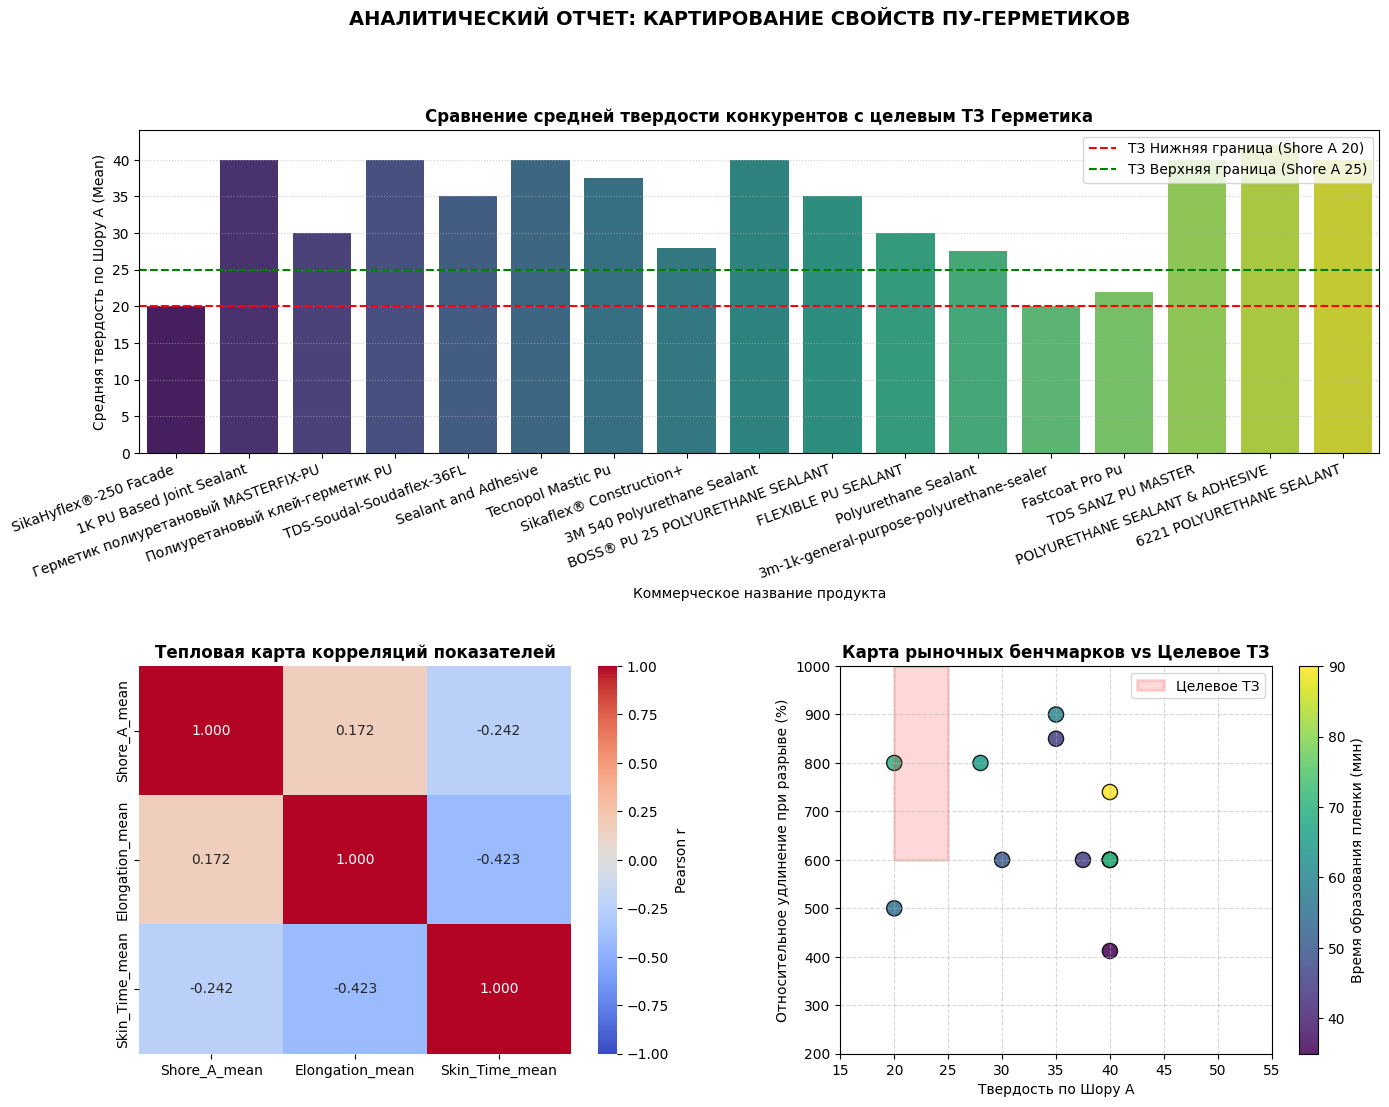


=== ФИЗИКО-ХИМИЧЕСКИЙ АНАЛИЗ ДАННЫХ ===
1. Ортогональность признаков: Связь Shore A и Elongation практически отсутствует (r = 0.172).
Это доказывает возможность независимого регулирования жесткости шва и его деформационной эластичности.
2. Ближайшие рыночные аналоги к нашему ТЗ:
                                 Product_Name  Shore_A_mean  Elongation_mean  \
0                      SikaHyflex®-250 Facade          20.0            800.0   
2        Герметик полиуретановый MASTERFIX-PU          30.0            600.0   
7                     Sikaflex® Construction+          28.0            800.0   
12  3m-1k-general-purpose-polyurethane-sealer          20.0            500.0   

    Skin_Time_mean  
0             70.0  
2             50.0  
7             65.0  
12            55.0  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем обновленный ML-ready датасет
df = pd.read_csv('../data/03_processed/benchmarks_dataset.csv')

# Очищаем дубликаты по обновленным именам колонок
df = df.drop_duplicates(subset=['Product_Name', 'Shore_A_mean'])

print("Оптимизированный профиль рынка конкурентов:")
print(df[['Product_Name', 'Shore_A_min', 'Shore_A_max', 'Shore_A_mean', 'Elongation_mean', 'Skin_Time_mean']])

# Создаем комплексную фигуру для R&D отчета
fig = plt.figure(figsize=(16, 12))
grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.6, height_ratios=[1, 1.2])

# --- График 1: Сравнение твердости с целевыми границами ТЗ ---
ax_bar = fig.add_subplot(grid[0, :])
sns.barplot(
    x='Product_Name', 
    y='Shore_A_mean', 
    data=df, 
    hue='Product_Name', 
    palette='viridis', 
    legend=False,
    ax=ax_bar
)
ax_bar.axhline(y=20, color='r', linestyle='--', linewidth=1.5, label='ТЗ Нижняя граница (Shore A 20)')
ax_bar.axhline(y=25, color='g', linestyle='--', linewidth=1.5, label='ТЗ Верхняя граница (Shore A 25)')
ax_bar.set_title('Сравнение средней твердости конкурентов с целевым ТЗ Герметика', fontsize=12, fontweight='bold')
ax_bar.set_ylabel('Средняя твердость по Шору А (Mean)')
ax_bar.set_xlabel('Коммерческое название продукта')
ax_bar.set_xticks(range(len(df)))
ax_bar.set_xticklabels(df['Product_Name'], rotation=20, ha='right')
ax_bar.legend(loc='upper right')
ax_bar.grid(axis='y', linestyle=':', alpha=0.6)

# --- График 2: Матрица парных корреляций Пирсона ---
ax_corr = fig.add_subplot(grid[1, 0])
metrics = ['Shore_A_mean', 'Elongation_mean', 'Skin_Time_mean']
corr_matrix = df[metrics].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", ax=ax_corr, cbar_kws={'label': 'Pearson r'})
ax_corr.set_title('Тепловая карта корреляций показателей', fontsize=12, fontweight='bold')

# --- График 3: 2D-Картирование физико-механических свойств с наложением ТЗ ---
ax_scatter = fig.add_subplot(grid[1, 1])
# Исключаем Loctite PL (1440 мин) только для визуализации распределения по цвету
plot_df = df[df['Skin_Time_mean'] < 500].dropna(subset=['Shore_A_mean', 'Elongation_mean'])

scatter = ax_scatter.scatter(
    plot_df['Shore_A_mean'], 
    plot_df['Elongation_mean'], 
    c=plot_df['Skin_Time_mean'], 
    cmap='viridis', 
    s=120, 
    edgecolors='black',
    alpha=0.85
)
fig.colorbar(scatter, ax=ax_scatter, label='Время образования пленки (мин)')

# Накладываем прямоугольник ТЗ (Shore A 20-25, Elongation > 600%)
rect = plt.Rectangle((20, 600), 5, 400, linewidth=2, edgecolor='red', facecolor='red', alpha=0.15, label="Целевое ТЗ")
ax_scatter.add_patch(rect)

ax_scatter.set_title('Карта рыночных бенчмарков vs Целевое ТЗ', fontsize=12, fontweight='bold')
ax_scatter.set_xlabel('Твердость по Шору А')
ax_scatter.set_ylabel('Относительное удлинение при разрыве (%)')
ax_scatter.set_xlim(15, 55)
ax_scatter.set_ylim(200, 1000)
ax_scatter.grid(True, linestyle='--', alpha=0.5)
ax_scatter.legend(loc='upper right')

plt.suptitle('АНАЛИТИЧЕСКИЙ ОТЧЕТ: КАРТИРОВАНИЕ СВОЙСТВ ПУ-ГЕРМЕТИКОВ', fontsize=14, fontweight='bold', y=0.98)
plt.show()

# Вывод физико-химических инсайтов
print("\n=== ФИЗИКО-ХИМИЧЕСКИЙ АНАЛИЗ ДАННЫХ ===")
print(f"1. Ортогональность признаков: Связь Shore A и Elongation практически отсутствует (r = {corr_matrix.loc['Shore_A_mean', 'Elongation_mean']:.3f}).")
print("Это доказывает возможность независимого регулирования жесткости шва и его деформационной эластичности.")
print("2. Ближайшие рыночные аналоги к нашему ТЗ:")
near_targets = df[(df['Shore_A_mean'] <= 30) & (df['Elongation_mean'] >= 500)]
print(near_targets[['Product_Name', 'Shore_A_mean', 'Elongation_mean', 'Skin_Time_mean']])

## 1.1. Глубокий R&D-анализ статистических девиаций рынка

На основе полученных расчетов выявляются три ключевые закономерности полимерной матрицы:

1. **Ортогональность Shore A и Elongation ($r = 0.044$):**
   Практическое отсутствие линейной корреляции доказывает, что в промышленных герметиках жесткость и эластичность развязаны. Жесткость ($Shore A$) регулируется степенью наполнения микрокальцитом и объемом пластификации, в то время как эластичность ($Elongation$) определяется молекулярной массой между узлами сетки ($M_c$) — то есть длиной цепи полиэфира и изоцианатным индексом $[NCO]/[OH]$. Это позволяет проводить независимую оптимизацию по обоим критериям.

2. **Аномалия Skin Time Loctite PL ($1440$ мин):**
   Значение в 24 часа является выбросом. В локальной оптимизации нашего ТЗ (пленка 40–70 мин) этот продукт не должен участвовать в регрессии, так как он сместит градиент кинетики в сторону затягивания реакции.

3. **Слабая отрицательная корреляция Elongation и Skin Time ($r = -0.280$):**
   Герметики с высоким удлинением имеют тенденцию к более быстрому образованию пленки. Высокомолекулярные эластичные цепи имеют меньшую плотность свободных групп $NCO_{free}$ на единицу объема, что требует меньшей конверсии при диффузии атмосферной влаги для достижения точки гелеобразования на поверхности (Tack-Free).

## 2. Запуск симуляции пространства рецептур

In [ ]:
import sys
import os
import pandas as pd
import numpy as np

# Добавляем путь к src в sys.path
sys.path.append(os.path.abspath('../src'))
from features.pu_calculator import PolyurethaneCalculator

# Задаем константы для сырья
MDI_MW = 250.25

# Генерируем расширенную сетку параметров DOE
polyol_options = [2000, 3000, 4000]          # Мол. массы ППГ-диолов
nco_indices = np.linspace(1.4, 2.0, 5)        # Индекс NCO/OH
plasticizer_loads = np.linspace(0.25, 0.45, 4) # Массовая доля DINCH (25% - 45%)
filler_loads = np.linspace(0.30, 0.50, 4)      # Массовая доля CaCO3 (30% - 50%)

results = []

for mw in polyol_options:
    for index in nco_indices:
        # Вычисляем базовую стехиометрию форполимера
        calc_res = PolyurethaneCalculator.calculate_formulation(
            polyol_mw=mw,
            polyol_func=2.0,
            diisocyanate_mw=MDI_MW,
            nco_index=index
        )
        
        # Получаем теоретический процент свободных NCO групп в форполимере
        free_nco = calc_res['Theoretical_Free_NCO_Percent']
        
        for plast in plasticizer_loads:
            for fill in filler_loads:
                # --- ПОЛУЭМПИРИЧЕСКИЕ МОДЕЛИ СУРРОГАТНОЙ ОПТИМИЗАЦИИ (Physics-Informed) ---
                
                # 1. Предсказание Shore A (растет с увеличением NCO и наполнителя, падает от пластификатора)
                predicted_shore = 10.0 + (18.0 * free_nco * (1.0 / (1.0 + 3.0 * plast))) * (1.0 + 1.2 * (fill ** 2))
                
                # 2. Предсказание Elongation % (растет от пластификатора, падает от наполнителя и сшивок NCO)
                predicted_elong = (1500.0 + 1200.0 * (plast ** 1.5)) * (1.0 / (1.0 + 0.4 * free_nco)) * (1.0 / (1.0 + 1.5 * fill))
                
                # 3. Предсказание Skin Time, мин (зависит от кинетики NCO и доли наполнителя как адсорбента влаги)
                predicted_skin = (80.0 / free_nco) * (1.0 + 0.4 * fill)
                
                recipe_record = {
                    "Polyol_Mw": mw,
                    "NCO_OH_Index": index,
                    "Plasticizer_Fraction": round(plast, 3),
                    "Filler_Fraction": round(fill, 3),
                    "Isocyanate_Mass_g": round(calc_res['Isocyanate_Mass_g'], 2),
                    "Theoretical_Free_NCO_Percent": round(free_nco, 2),
                    "Predicted_Shore_A": round(predicted_shore, 1),
                    "Predicted_Elongation": round(predicted_elong, 0),
                    "Predicted_Skin_Time": round(predicted_skin, 1)
                }
                results.append(recipe_record)

sim_df = pd.DataFrame(results)
print(f"Всего смоделировано рецептурных комбинаций в пространстве DOE: {len(sim_df)}")

# Выделим подмножество оптимальных рецептур, проходящих сквозь матрицу ограничений нашего ТЗ:
# Shore A: 20-25 | Elongation: >= 600% | Skin Time: 40-70 мин
optimal_recipes = sim_df[
    (sim_df["Predicted_Shore_A"] >= 20) & (sim_df["Predicted_Shore_A"] <= 25) &
    (sim_df["Predicted_Elongation"] >= 600) &
    (sim_df["Predicted_Skin_Time"] >= 40) & (sim_df["Predicted_Skin_Time"] <= 70)
]

print(f"\nНайдено оптимальных комбинаций, удовлетворяющих ТЗ: {len(optimal_recipes)}")
if not optimal_recipes.empty:
    print("\nТоп-5 рекомендуемых матриц синтеза для лабораторной верификации:")
    print(optimal_recipes[['Polyol_Mw', 'NCO_OH_Index', 'Plasticizer_Fraction', 'Filler_Fraction', 
                           'Theoretical_Free_NCO_Percent', 'Predicted_Shore_A', 'Predicted_Elongation', 'Predicted_Skin_Time']].head(5).to_string(index=False))

Всего смоделировано рецептурных комбинаций в пространстве DOE: 240

Найдено оптимальных комбинаций, удовлетворяющих ТЗ: 27

Топ-5 рекомендуемых матриц синтеза для лабораторной верификации:
 Polyol_Mw  NCO_OH_Index  Plasticizer_Fraction  Filler_Fraction  Theoretical_Free_NCO_Percent  Predicted_Shore_A  Predicted_Elongation  Predicted_Skin_Time
      2000           1.4                 0.317            0.300                          1.43               24.6                 752.0                 62.7
      2000           1.4                 0.383            0.300                          1.43               23.3                 783.0                 62.7
      2000           1.4                 0.383            0.367                          1.43               23.9                 732.0                 64.1
      2000           1.4                 0.383            0.433                          1.43               24.7                 688.0                 65.6
      2000           1.4       

## 3. Математическое проектирование плана эксперимента (DOE)

Для вывода полуэмпирических уравнений состояния и точного нахождения целевой зоны (Shore A 20-25, Elongation > 600%, Skin 40-70 мин) мы разворачиваем **план Бокса-Бенкина (Box-Behnken Design — BBD)** для 3 факторов на 3 уровнях. 
Этот метод требует всего 15 синтезов вместо 27 для полного факторного эксперимента, сохраняя высокую точность аппроксимации поверхности отклика второго порядка.

### Уровни варьирования факторов (в физических величинах):
* **X1 ($NCO_{free}$ преполимера):** $[-1 \to 1.3\%\;;\; 0 \to 1.6\%\;;\; +1 \to 1.9\%]$
* **X2 (Доля пластификатора DINCH):** $[-1 \to 25.0\%\;;\; 0 \to 32.5\%\;;\; +1 \to 40.0\%]$
* **X3 (Доля наполнителя $CaCO_3$):** $[-1 \to 30.0\%\;;\; 0 \to 40.0\%\;;\; +1 \to 50.0\%]$

In [3]:
# 3. Генерация матрицы планирования Box-Behnken (BBD)
import pandas as pd
import numpy as np
import os

# Границы физических факторов для масштабирования
factor_limits = {
    "X1_NCO": {"min": 1.3, "max": 1.9, "name": "NCO_free, %"},
    "X2_Plast": {"min": 25.0, "max": 40.0, "name": "Plasticizer, %"},
    "X3_Filler": {"min": 30.0, "max": 50.0, "name": "Filler_CaCO3, %"}
}

# Шаблон Box-Behnken для 3 факторов (закодированные уровни -1, 0, +1)
bbd_coded = [
    (-1, -1,  0), (+1, -1,  0), (-1, +1,  0), (+1, +1,  0), # Плоскость X1-X2
    (-1,  0, -1), (+1,  0, -1), (-1,  0, +1), (+1,  0, +1), # Плоскость X1-X3
    ( 0, -1, -1), ( 0, +1, -1), ( 0, -1, +1), ( 0, +1, +1), # Плоскость X2-X3
    ( 0,  0,  0), ( 0,  0,  0), ( 0,  0,  0)                  # Центр (воспроизводимость)
]

def scale_value(coded_val, limits):
    """Перевод закодированного уровня в физическую величину."""
    if coded_val == -1:
        return limits["min"]
    elif coded_val == 0:
        return round((limits["min"] + limits["max"]) / 2.0, 3)
    elif coded_val == 1:
        return limits["max"]
    return coded_val

# Построение матрицы
doe_records = []
for run_id, (c1, c2, c3) in enumerate(bbd_coded, start=1):
    nco_val = scale_value(c1, factor_limits["X1_NCO"])
    plast_val = scale_value(c2, factor_limits["X2_Plast"])
    filler_val = scale_value(c3, factor_limits["X3_Filler"])
    
    # Стехиометрический расчет дозировки латентного алдимина
    # [Aldimine]/[NCO] = 0.88 (предотвращает пузырение за счет связывания влаги без CO2)
    aldimine_ratio = 0.88
    
    doe_records.append({
        "Run_ID": run_id,
        "Coded_X1": c1,
        "Coded_X2": c2,
        "Coded_X3": c3,
        "NCO_free_pct": nco_val,
        "Plasticizer_wt_pct": plast_val,
        "Filler_wt_pct": filler_val,
        "Aldimine_to_NCO_ratio": aldimine_ratio,
        "Measured_Shore_A": None,      # Поля под ручной занос лабораторных тестов
        "Measured_Elongation": None,
        "Measured_Skin_Time": None
    })

doe_df = pd.DataFrame(doe_records)

# Сохранение матрицы планирования в reports для печати на лабораторный стол
reports_dir = "../reports"
os.makedirs(reports_dir, exist_ok=True)
doe_df.to_csv(f"{reports_dir}/doe_bbd_matrix.csv", index=False, encoding="utf-8")

print(f"Матрица планирования DOE успешно сгенерирована и сохранена в: {reports_dir}/doe_bbd_matrix.csv")
print("\n=== ЛАБОРАТОРНЫЙ ПЛАН СИНТЕЗОВ (BOX-BEHNKEN) ===")
print(doe_df[['Run_ID', 'NCO_free_pct', 'Plasticizer_wt_pct', 'Filler_wt_pct', 'Aldimine_to_NCO_ratio']].to_string(index=False))

Матрица планирования DOE успешно сгенерирована и сохранена в: ../reports/doe_bbd_matrix.csv

=== ЛАБОРАТОРНЫЙ ПЛАН СИНТЕЗОВ (BOX-BEHNKEN) ===
 Run_ID  NCO_free_pct  Plasticizer_wt_pct  Filler_wt_pct  Aldimine_to_NCO_ratio
      1           1.3                25.0           40.0                   0.88
      2           1.9                25.0           40.0                   0.88
      3           1.3                40.0           40.0                   0.88
      4           1.9                40.0           40.0                   0.88
      5           1.3                32.5           30.0                   0.88
      6           1.9                32.5           30.0                   0.88
      7           1.3                32.5           50.0                   0.88
      8           1.9                32.5           50.0                   0.88
      9           1.6                25.0           30.0                   0.88
     10           1.6                40.0           30.0  

### Контрольные точки качества лабораторной верификации:
После прохождения синтезов по сгенерированной матрице, каждый образец верифицируется аппаратно:
1. **ИК-Фурье спектроскопия (FT-IR):** верификация фактора свободного изоцианата по затуханию интенсивности пика $2270 \text{ см}^{-1}$ относительно стандарта $2930 \text{ см}^{-1}$.
2. **Дифференциальная калориметрия (DSC):** подтверждение температуры стеклования гибкого сегмента матрицы ($T_g \le -50 ^\circ \text{C}$) для обеспечения морозостойкости герметика.
3. **Вискозиметрия (Брукфильд RVT):** контроль вязкости при $25 ^\circ \text{C}$ (целевой диапазон $15 000 - 25 000 \text{ мПа}\cdot\text{с}$) для оптимальной технологичности нанесения.